----

----

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv') #completa el código

In [ ]:
traffic.head()# mostrar las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head() # mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [ ]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo object (texto) cuando deberían ser de tipo datetime para poder extraer el año y hacer análisis temporales.
- Las columnas numericas son de tipo float64 (número con decimal), por lo que no es necesario realizar correcciones de formato.
- No hay datos nulos en las columnas de este df.

In [ ]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, object (texto), cuando deberían de ser tipo float64 para poder realizar los cálculos correspondientes. Hay que realizar la corrección de los datos para el análisis.
- El formato de los números también complica la lectura de los mismos, `City GDP/capita` tiene puntos como separadores de miles y comas como decimales. `Unemployment %` usa símbolo de porcentaje en el dato. `PM2.5 (μg/m³)` y `Population (M)`, usan comas como separadores de decimales.
- La columna `Year` está en el formato correcto, int64 (número entero)
- No hay valores nulos en ninguna columna del df.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={
    'Country':'country',
    'City':'city',
    'UpdateTimeUTC':'update_time_utc',
    'JamsDelay':'jams_delay',
    'TrafficIndexLive':'traffic_index_live',
    'JamsLengthInKms':'jams_length_in_kms',
    'JamsCount':'jams_count',
    'TrafficIndexWeekAgo':'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo':'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins':'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins':'travel_time_historic_per_10kms_mins',
    'MinsDelay':'mins_delay'
})
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={
    'Year':'year',
    'City':'city',
    'Country':'country',
    'City GDP/capita':'city_gdp_capita',
    'Unemployment %':'unemployment_pct',
    'PM2.5 (μg/m³)':'pm25',
    'Population (M)':'population_m'
})
# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc']) #tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago']) #tu código aquí

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
# eco['city_gdp_capita'] = ....astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
# eco['unemployment_pct'] = ...
# eco['population_m'] = ...
eco['city_gdp_capita'] = (eco['city_gdp_capita']
                          .astype(str)
                          .str.replace('.', '', regex=False)  # Especifica regex=False
                          .str.replace(',', '.', regex=False)
                          .astype(float))
eco['unemployment_pct'] = (eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float))
eco['pm25'] = (eco['pm25'].astype(str).str.replace(',', '.').astype(float))
eco['population_m'] = (eco['population_m'].astype(str).str.replace(',', '.').astype(float))
# Calcula la población total en unidades absolutas (Multiplica * 1000000)
# eco['population'] = ...
eco['population'] = eco['population_m']* 1000000
# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,1578200.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,1447500.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,1314200.0,9.8,19.1,13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc
# traffic['year'] = ...
traffic['year'] = traffic['update_time_utc'].dt.year
# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
# traffic_2024 = traffic[...].copy()
# eco_2024 = ...
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year']==2024].copy()
# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,1811700.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,1470300.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,1334900.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,1625100.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,889900.0,12.4,15.2,3.9,3900000.0


In [ ]:
# VALIDACIÓN: Verificar que el filtrado funcionó
print("Años únicos en el dataset filtrado:")
print(traffic_2024['year'].unique())

Años únicos en el dataset filtrado:
[2024]


In [ ]:
# O también puedes usar value_counts para ver la distribución
print("\nConteo de registros por año:")
print(traffic_2024['year'].value_counts())


Conteo de registros por año:
2024    886779
Name: year, dtype: int64



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
# Calcular los promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(["city","country","year"])\
                        .agg({'jams_delay':'mean',
                              'traffic_index_live':'mean',
                              'jams_length_in_kms': 'mean',
                              'jams_count': 'mean',
                              'mins_delay': 'mean',
                              'travel_time_live_per_10kms_mins': 'mean',
                              'travel_time_historic_per_10kms_mins': 'mean'})\
                        .reset_index()
# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [ ]:
# tu código aquí
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Mexico-City, con 2833.05 segundos, o lo que sería igual a 47.2 minutos adicionales a su tiempo de traslado regular, que la población pierde su tiempo en el tráfico de la Ciudad de México.


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
# traffic_2024_small = traffic_city_year_2024[ ... ].copy()
# eco_2024_small = ...
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()
# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small,on=['city','year'],how='inner') # tu código aquí

# Mostrar las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,1112400.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,1144200.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,1625100.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,1811700.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,1238100.0,8.2,13.5,3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

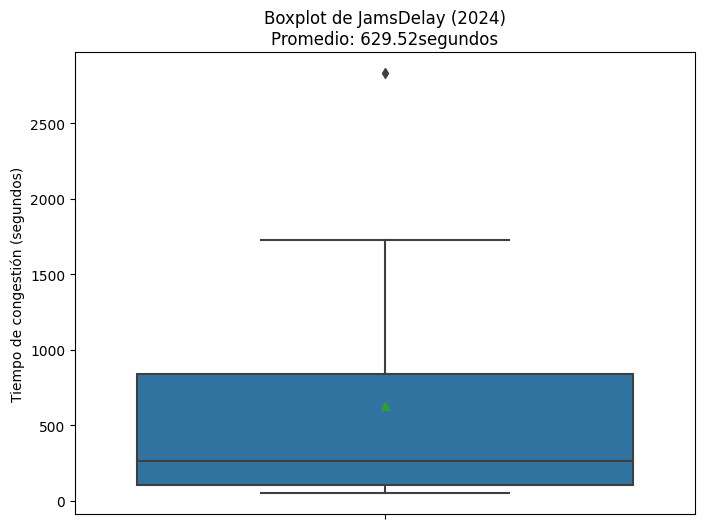

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
plt.figure(figsize=(8,6))
sns.boxplot(data=merged,y='jams_delay',showmeans=True)
# Obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}segundos')
plt.ylabel('Tiempo de congestión (segundos)')
plt.show()


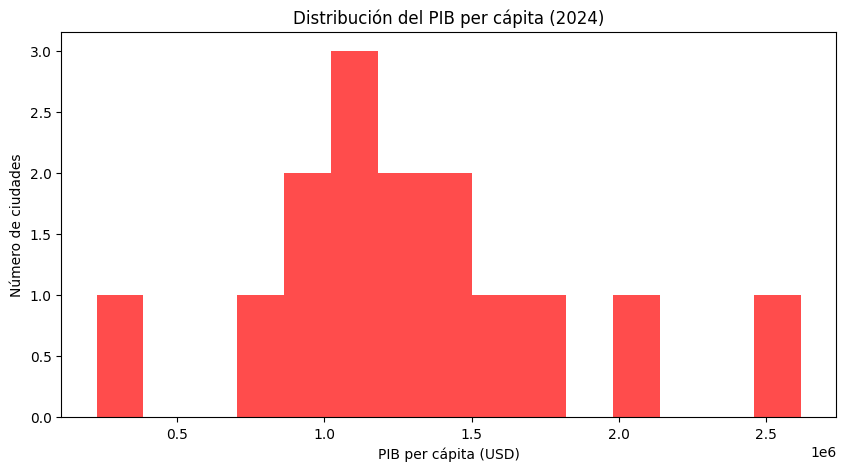

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
plt.figure(figsize=(10,5))
plt.hist(merged['city_gdp_capita'],bins=15,alpha=0.7,color='red')
plt.title('Distribución del PIB per cápita (2024)')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Número de ciudades')
plt.show()

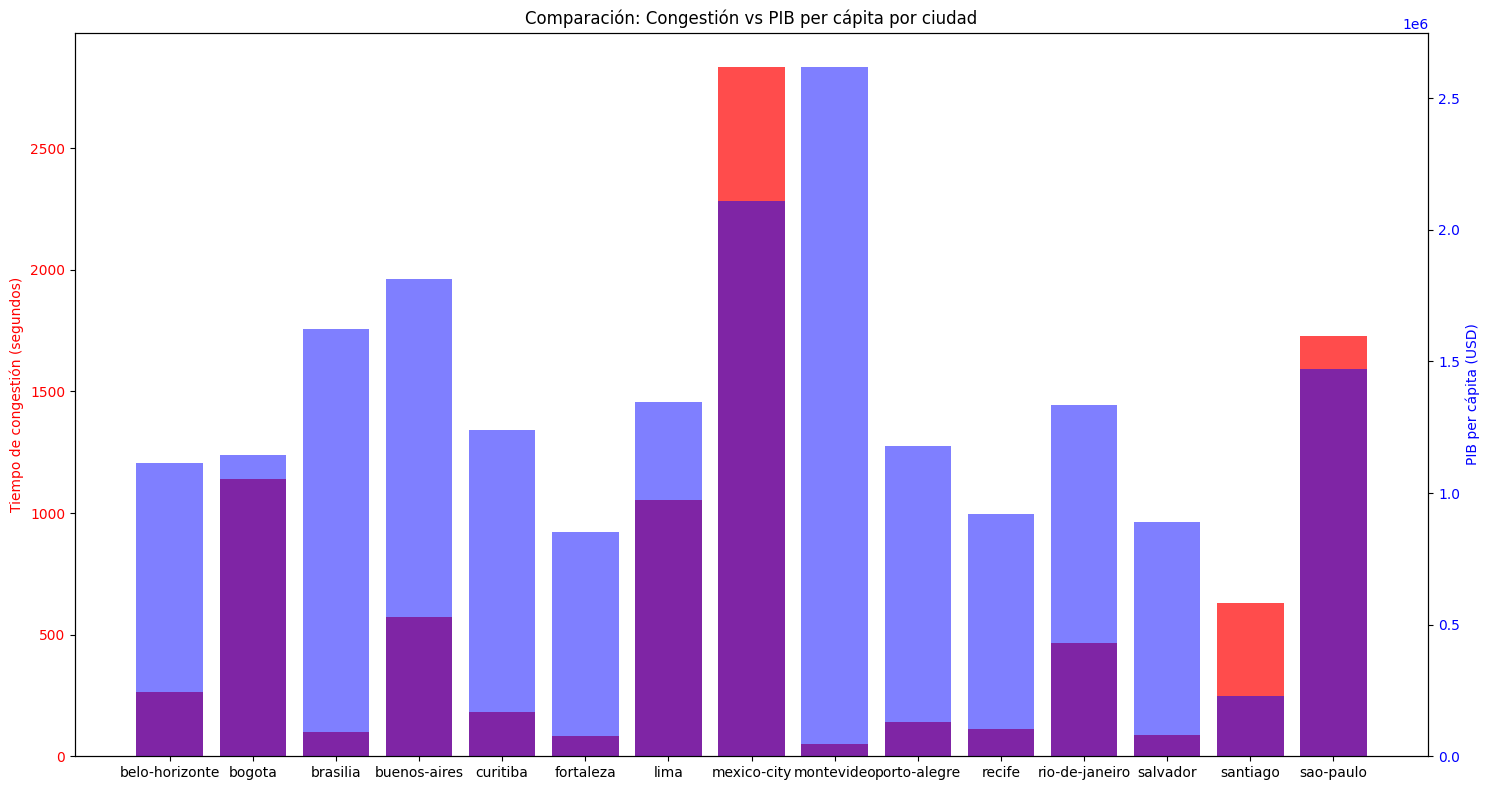

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])
fig, ax1 = plt.subplots(figsize=(15, 8))
ax1.bar(merged['city'], merged['jams_delay'], alpha=0.7, color='red', label='Congestión (seg)')
ax1.set_ylabel('Tiempo de congestión (segundos)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax2 = ax1.twinx()
ax2.bar(merged['city'], merged['city_gdp_capita'], alpha=0.5, color='blue', label='PIB per cápita (USD)')
ax2.set_ylabel('PIB per cápita (USD)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
plt.title('Comparación: Congestión vs PIB per cápita por ciudad')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: No existe una relación clara, si tomamos en cuenta factores como la conciencia vial de algunas ciudades, donde no hay planes o programas reales y medibles para corroborar su efectividad, la existencia de una alta flota vehicular en los países con altos tiempos de congestión; se puede concluir que a menor conciencia vial, el tiempo de congestión aumenta. Si se planearan y ejecutaran de una manera más conciente y efectiva, tanto una diversidad de medios de transporte, y buena conducta civica al volante, los tiempos se podrían llegar a disminuir. Pero usualmente, las ciudades con alta densidad poblacional, evitan que se pueda plantear programas y medidas ejecutables en el corto y mediano plazo, más que nada por el cambio constante en la densidad poblacional de estás ciudades, que año con año se ve como aumenta la demanda por habitar estás ciudades.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información.


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.
- En las ciudades donde se llega a concentrar la actividad empresarial de los países, tiene un impacto importante.
- El PIB, groso modo se compone de los siguientes factores: PIB = Consumo + Inv + Gsto Pub + (Export - Import).
- Si se añade el factor de que la gente pierde mucho tiempo desplazandose, nos indica que el país o ciertas partes, está siendo menos productivo, menos consumo, si el gobienro no invierte en infraestructura, si el gasto público se ocupa para otros fines, tenemos la formula para que los países vean su PIB comprometido en ciertas áreas.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.
- El periodo de análisis fue el año 2024. En este periodo solo se analizo 15 ciudades, distribuidas en 7 países que son (Brasil, Argentina, Chile, Colombia, México, Peru, Uruguay).

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).
- El proyecto se derivó de 6 pasos, de los cuales se inició con:
- 1.-La carga y exploración de los archivos.
- 2.- Limpieza y corrección de datos estandarizando los nombres de las columnas y corrección en tipo de datos, ya que algunos datos numéricos como las fechas o datos de medición aparecían como datos de texto, se empleó .to_datetime y .astype(float) para ese fin.
- 3.- Se procedió a extraer el año y filtrar los datos a analizar para obtener solo el periodo de 2024, con las funciones .dt.year para extraer solo el año de las fechas completas, y luego filtrando por la información mencionada, del 2024.
- 4.- Se calcularon los promedios del tráfico por ciudad, para que se pudiera visualizar cuáles eran las que contaban con los periodos de tiempo más amplios. Se ocuparon funciones de agregación (.agg) para obtener los promedios.
- 5.- Se procedió a unir los dos datasets para tener una sola tabla y analizar cómo se relacionan los indicadores económicos con los de movilidad, se ocupó la función de .merge con una unión "inner".
- 6.-Se generaron los gráficos con el resultado de la unión de tablas para poder visualizar mejor los datos extraídos. Se empleó la biblioteca de seaborn y matplotlib.pyplot para generar los gráficos.

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Después de obtener el gráfico que compara ambos índices, hay ciudades con un alto PIB, pero con bajos niveles de índice de tráfico, hay otros lugares, con alto PIB, y con altos índices de tráfico. Por lo que el patrón más visible en el gráfico, el cual es más PIB en relación con altos índices de tráfico, se puede relacionar con la posibilidad de tener un automóvil como medio de transporte personal, u ocupar otros medios de transporte alternativos, como el servicio público, o medios de transporte ecológicos como la bicicleta.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.
- En cuanto a la interpretación del boxplot y la adición del promedio para compararlo con la mediana, aunque hay una separación entre ambos, siguen coexistiendo dentro de la misma caja, lo cual hace referencia a que la mayoría de los países tienen tiempos de congestión vehicular muy parecidos. El outlier que se aprecia, y el cual pertenece a las mediciones de México, se puede entender, y no es un error de captura, ya que los tiempos de movilidad dentro de Ciudad de México no son amigables para los habitantes de la ciudad, comó se puede apreciar en el valor calculado, el promedio de tiempo adicional que se necesita para hacer un trayecto dentro de Ciudad de México, puede aumentar hasta en 47 minutos adicionales en comparación con otros países graficados.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?
- Entre las tres ciudades mencionadas, Bogotá es la que está más cerca de tener un punto de equilibrio entre congestión vehicular y PIB, por lo que se pueden recomendar acciones para que la movilidad sea más amigable para la sociedad, y la calidad de vida y la productividad puedan tener una mejora para la población.
- En casos aparte Ciudad de México, y Sao-Paulo tienen evidentes problemas de movilidad y de altisimos niveles de congestión vehicular, que a pesar de tener una correlación muy cercana con el PIB, eso no resta valor a proponer acciones y modelos de infraestructura que hagan que la movilidad se pueda mejorar, al ser ciudades con altos índices de población, los sistemas de transporte públicos también evidencian una alta afluencia de personas en hora pico de estas dos ciudades, y donde una inversión en infraestructura vehicular no siginificaría una mejora inmediata para disminuir los niveles de congestión vehicular. En algunos países europeos, el caso particular de Países Bajos, que entre 1960 a 1973 pasó de ser uno de los países con una tasa de accidentes alta, con una relación directa de la crisis del petróleo del año de 1973, logró incentivar a la población en general en el uso de la bicicleta como principal medio de transporte, eso no solo ayudo a que el PIB tuviera una mejora al reducir drasticamente la importación del combustible para los autos, si no que mejoro la movilidad en las ciudades importantes, como Amsterdam, Roterdam. Puede que sean ejemplos con realidades diferentes, pero la necesidad de cambio, ayudo a la adopción de medidas que a la postre ayudaron a que la población estuviera más cómoda con su entorno, y sus tiempos.


In [ ]:
# Ver qué países específicos están incluidos
num_paises = merged['country'].nunique()
print(f"Número de países en la muestra: {num_paises}")

Número de países en la muestra: 7


In [ ]:
# Ver cuántas ciudades hay por cada país
ciudades_por_pais = merged.groupby('country')['city'].nunique().sort_values(ascending=False)
print("Número de ciudades por país:")
print(ciudades_por_pais)

Número de ciudades por país:
country
BRA    9
ARG    1
CHL    1
COL    1
MEX    1
PER    1
URY    1
Name: city, dtype: int64


In [ ]:
# Ver qué países específicos están incluidos
paises_incluidos = merged['country'].unique()
print("Países incluidos en la muestra:")
for pais in sorted(paises_incluidos):
    print(f"- {pais}")

Países incluidos en la muestra:
- ARG
- BRA
- CHL
- COL
- MEX
- PER
- URY
